In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [2]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

In [3]:
print("Original dataset shape:", data.shape)
print("\n" + "="*60)
print("FEATURE ENGINEERING & PREPROCESSING")
print("="*60)

Original dataset shape: (100000, 31)

FEATURE ENGINEERING & PREPROCESSING


In [4]:
print("\n1. CREATING NEW FEATURES...")


1. CREATING NEW FEATURES...


In [6]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
data['bmi_category'] = data['bmi'].apply(categorize_bmi)

In [7]:
def categorize_age(age):
    if age < 30:
        return 'Young'
    elif 30 <= age < 50:
        return 'Middle'
    elif 50 <= age < 70:
        return 'Senior'
    else:
        return 'Elderly'
data['age_group'] = data['age'].apply(categorize_age)

In [9]:
data.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes', 'bmi_category', 'age_group'],
      dtype='object')

In [11]:
data['metabolic_syndrome_risk'] = (
    (data['bmi'] >= 25).astype(int) + # Overweight
    (data['glucose_fasting'] >= 100).astype(int) + # High fasting glucose
    (data['triglycerides'] >= 150).astype(int) + # High triglycerides
    (data['hdl_cholesterol'] < 40).astype(int) + # Low HDL
    (data['systolic_bp'] >= 130).astype(int) # High BP
)

In [12]:
data['lifestyle_score'] = (
    (data['physical_activity_minutes_per_week'] / 100) +
    (data['diet_score'] / 10) +
    (data['sleep_hours_per_day'] / 8) -
    (data['alcohol_consumption_per_week'] / 5) -
    (data['screen_time_hours_per_day'] / 8)
)

In [13]:
data['cholesterol_ratio'] = data['cholesterol_total'] / data['hdl_cholesterol']

In [14]:
data['glucose_variability'] = data['glucose_postprandial'] - data['glucose_fasting']

In [15]:
data.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes', 'bmi_category', 'age_group',
       'metabolic_syndrome_risk', 'lifestyle_score', 'cholesterol_ratio',
       'glucose_variability'],
      dtype='object')

In [16]:
print("\n2. HANDLING OUTLIERS...")
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower_bound, upper_bound)


2. HANDLING OUTLIERS...


In [17]:
outlier_columns = [
'physical_activity_minutes_per_week', 'bmi', 'systolic_bp', 'diastolic_bp',
'heart_rate', 'glucose_fasting', 'glucose_postprandial', 'hba1c',
'triglycerides', 'ldl_cholesterol', 'insulin_level'
]
for col in outlier_columns:
    data[col] = cap_outliers(data[col])
    print(f"Capped outliers for: {col}")

Capped outliers for: physical_activity_minutes_per_week
Capped outliers for: bmi
Capped outliers for: systolic_bp
Capped outliers for: diastolic_bp
Capped outliers for: heart_rate
Capped outliers for: glucose_fasting
Capped outliers for: glucose_postprandial
Capped outliers for: hba1c
Capped outliers for: triglycerides
Capped outliers for: ldl_cholesterol
Capped outliers for: insulin_level


In [20]:
print("\n3. ENCODING CATEGORICAL VARIABLES...")
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")


3. ENCODING CATEGORICAL VARIABLES...
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage', 'bmi_category', 'age_group']


In [22]:
data['diabetes_stage'].nunique

<bound method IndexOpsMixin.nunique of 0              Type 2
1         No Diabetes
2              Type 2
3              Type 2
4              Type 2
             ...     
99995    Pre-Diabetes
99996    Pre-Diabetes
99997     No Diabetes
99998    Pre-Diabetes
99999    Pre-Diabetes
Name: diabetes_stage, Length: 100000, dtype: object>

In [23]:
diabetes_stage_order = {'No Diabetes': 0, 'Pre-Diabetes': 1, 'Gestational': 2, 'Type 2':3}
data['diabetes_stage_encoded'] = data['diabetes_stage'].map(diabetes_stage_order)

In [24]:
categorical_cols = [col for col in categorical_cols if col != 'diabetes_stage']

In [30]:
# Create a preprocessing pipeline WITH imputers
temp_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', StandardScaler())
         ]), 
         numerical_cols),
        
        ('cat', 
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
         ]), 
         categorical_cols)
    ]
)

# Transform features
X_temp = temp_preprocessor.fit_transform(X)

# Get feature names after OHE
cat_encoder = temp_preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)

all_feature_names = numerical_cols + list(cat_feature_names)
print(f"Total features after encoding: {len(all_feature_names)}")

# Feature selection
selector = SelectKBest(score_func=f_classif, k=30)
X_selected = selector.fit_transform(X_temp, y)

# Correct list comprehension
selected_mask = selector.get_support()
selected_features = [all_feature_names[i] for i in range(len(all_feature_names)) if selected_mask[i]]

print(f"Selected {len(selected_features)} most important features")


Total features after encoding: 60
Selected 30 most important features


In [31]:
X = data.drop("diagnosed_diabetes", axis=1)
y = data["diagnosed_diabetes"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
# Define your intended columns
numeric_features = [col for col in data.select_dtypes(include=[np.number]).columns if col not in ['diabetes_stage', 'diabetes_risk_score']]
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()

# --- SAFE COLUMN HANDLING BEFORE PIPELINE ---
num_cols = [c for c in numeric_features if c in X_train.columns]
cat_cols = [c for c in categorical_features if c in X_train.columns]

# Build ColumnTransformer (NO LAMBDAS)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"   # or "passthrough"
)

# Build pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

# Fit/transform
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Final processed training data shape:", X_train_processed.shape)
print("Final processed testing data shape:", X_test_processed.shape)


Final processed training data shape: (80000, 64)
Final processed testing data shape: (20000, 64)


In [51]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
print(feature_names)

['num__age' 'num__alcohol_consumption_per_week'
 'num__physical_activity_minutes_per_week' 'num__diet_score'
 'num__sleep_hours_per_day' 'num__screen_time_hours_per_day'
 'num__family_history_diabetes' 'num__hypertension_history'
 'num__cardiovascular_history' 'num__bmi' 'num__waist_to_hip_ratio'
 'num__systolic_bp' 'num__diastolic_bp' 'num__heart_rate'
 'num__cholesterol_total' 'num__hdl_cholesterol' 'num__ldl_cholesterol'
 'num__triglycerides' 'num__glucose_fasting' 'num__glucose_postprandial'
 'num__insulin_level' 'num__hba1c' 'num__diabetes_risk_score'
 'num__metabolic_syndrome_risk' 'num__lifestyle_score'
 'num__cholesterol_ratio' 'num__glucose_variability'
 'num__diabetes_stage_encoded' 'cat__gender_Female' 'cat__gender_Male'
 'cat__gender_Other' 'cat__ethnicity_Asian' 'cat__ethnicity_Black'
 'cat__ethnicity_Hispanic' 'cat__ethnicity_Other' 'cat__ethnicity_White'
 'cat__education_level_Graduate' 'cat__education_level_Highschool'
 'cat__education_level_No formal' 'cat__education_l

In [41]:
data.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes', 'bmi_category', 'age_group',
       'metabolic_syndrome_risk', 'lifestyle_score', 'cholesterol_ratio',
       'glucose_variability', 'diabetes_stage_encoded'],
      dtype='object')

#### Decision Tree Model Fit

In [54]:
## Decision Tree Classifier with Encoded Data
dt_classifier_encoded = DecisionTreeClassifier(random_state=42)
dt_classifier_encoded.fit(X_train_processed, y_train)
y_pred_dt_encoded = dt_classifier_encoded.predict(X_test_processed)
print("Decision Tree Classifier with Encoded Data Accuracy:", accuracy_score(y_test, y_pred_dt_encoded))
print(classification_report(y_test, y_pred_dt_encoded))

Decision Tree Classifier with Encoded Data Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Confusion Matrix:
 [[ 7993     7]
 [    5 11995]]


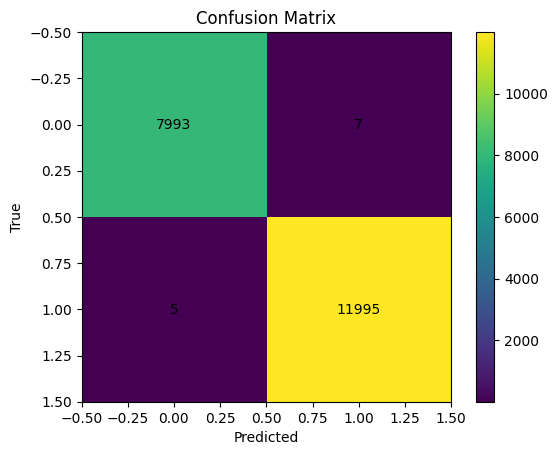

In [55]:
# Decision Tree Confusion Metrics
cm = confusion_matrix(y_test,y_pred_dt_encoded)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

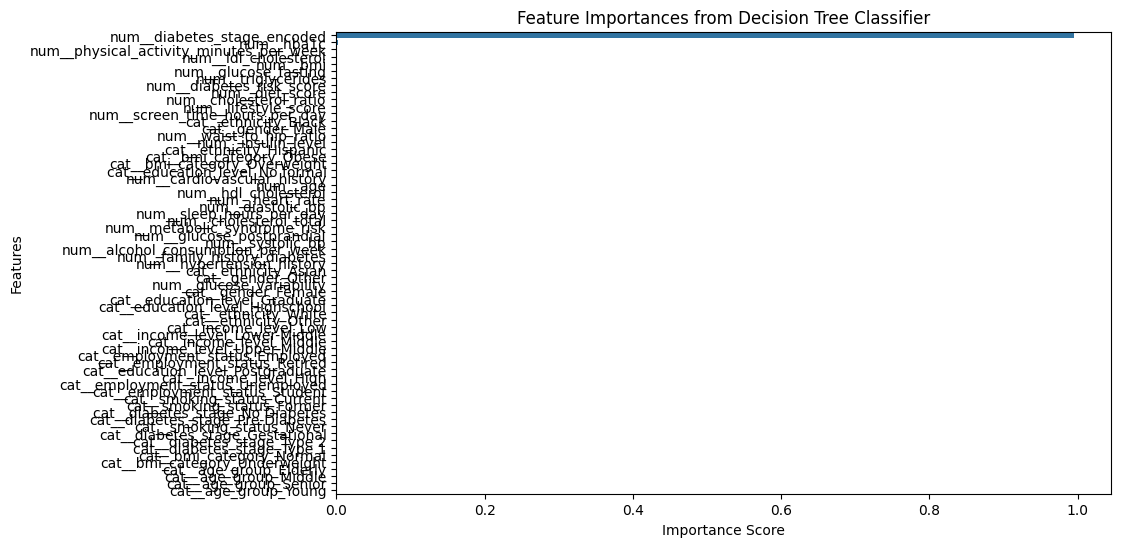

In [46]:
# Decision Tree Ferture Importance
feature_importances = pd.Series(dt_classifier_encoded.feature_importances_, index=feature_names)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Random Forest Model Fit

In [56]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_processed, y_train)
y_pred_rf = rf_classifier.predict(X_test_processed)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.99965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Confusion Matrix:
 [[ 7999     1]
 [    6 11994]]


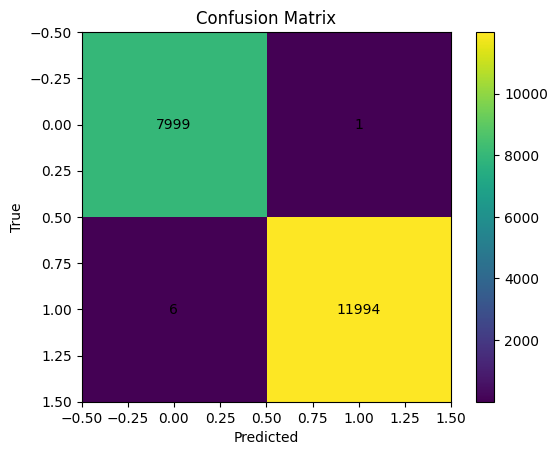

In [57]:
cm = confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

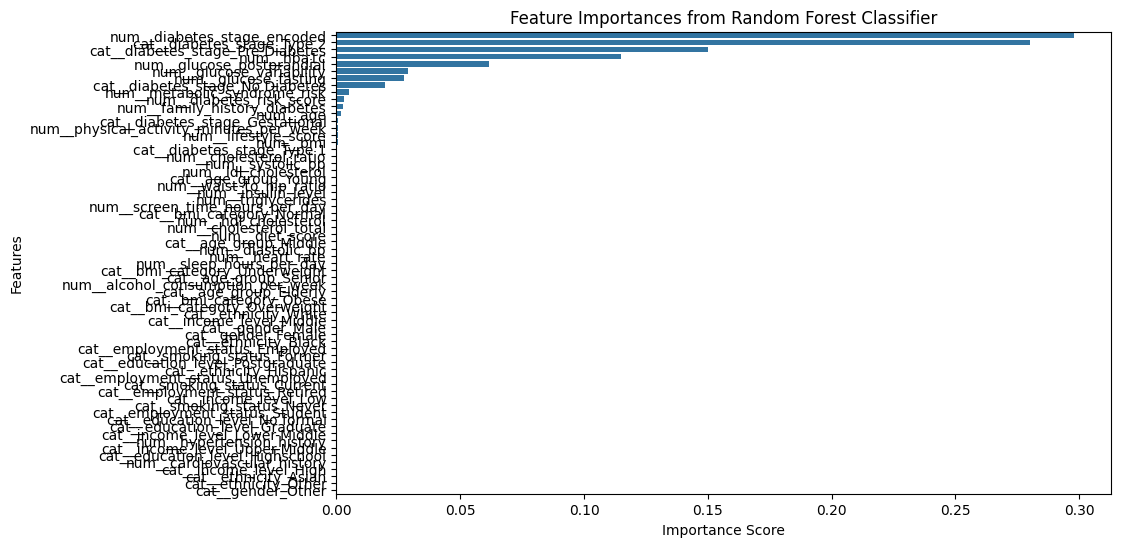

In [49]:
# random forest feature importance
rf_feature_importances = pd.Series(rf_classifier.feature_importances_, index=feature_names)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feature_importances, y=rf_feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Gradian Boost Model Fit

In [59]:
# Build a pipeline with imputer + classifier
gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing numeric values with median
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Fit the pipeline on training data
gb_pipeline.fit(X_train_processed, y_train)

# Predict
y_pred_gb = gb_pipeline.predict(X_test_processed)

# Predicted probabilities for ROC AUC
y_prob_gb = gb_pipeline.predict_proba(X_test_processed)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred_gb)
roc_auc = roc_auc_score(y_test, y_prob_gb)

print("Accuracy:", accuracy)
print("ROC AUC Score:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.9997
ROC AUC Score: 0.99999878125

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Confusion Matrix:
 [[ 8000     0]
 [    6 11994]]


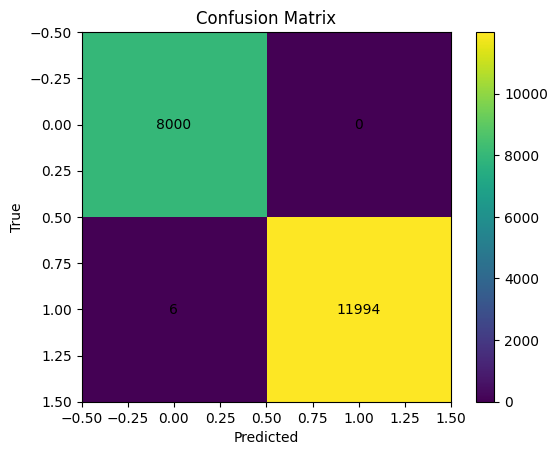

In [60]:
# Gradiant Confusion Metrics
cm = confusion_matrix(y_test,y_pred_gb)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

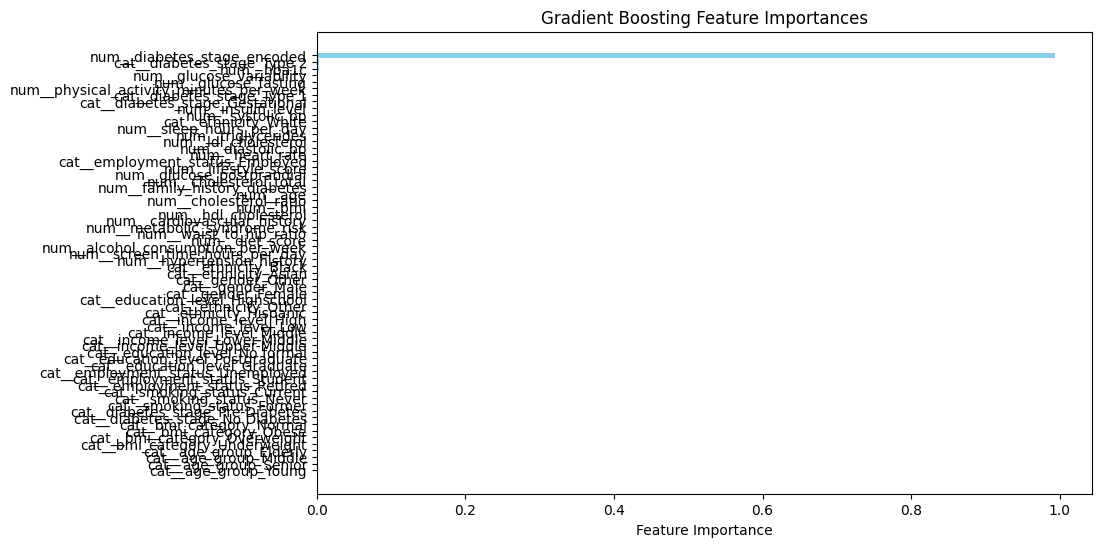

In [61]:

# Get feature names from your preprocessing pipeline
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances from the trained model
feature_importances_gb = gb_pipeline.named_steps["classifier"].feature_importances_

# Map feature importances to feature names
importance_df_gb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_gb
})

# Sort features by importance
importance_df_gb = importance_df_gb.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df_gb['Feature'], importance_df_gb['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importances')
plt.show()

#### logistic Regression Model Fit

In [63]:
# Build pipeline with imputer + logistic regression
logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # fill NaNs with median
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the pipeline
logreg_pipeline.fit(X_train_processed, y_train)

# Predict
y_pred_logreg = logreg_pipeline.predict(X_test_processed)

# Evaluate
accuracy = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Classifier Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression Classifier Accuracy: 0.99915

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Confusion Matrix:
 [[ 7990    10]
 [    7 11993]]


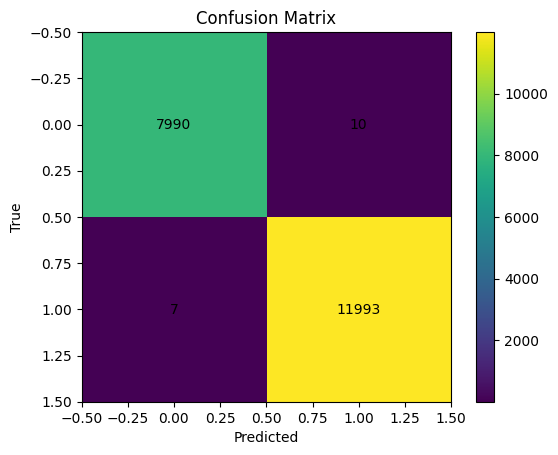

In [64]:
cm = confusion_matrix(y_test,y_pred_logreg)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

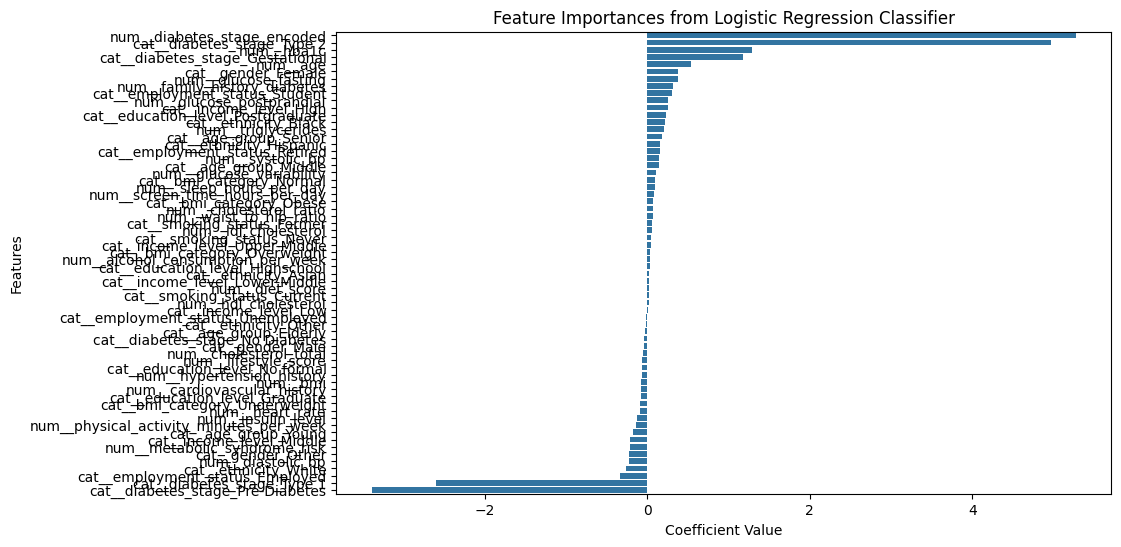

In [65]:
# Get feature names from the preprocessing pipeline
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression model from the pipeline
logreg_model = logreg_pipeline.named_steps["classifier"]

# Create a Series with coefficients
logreg_feature_importances = pd.Series(logreg_model.coef_[0], index=feature_names)

# Sort by absolute importance
logreg_feature_importances = logreg_feature_importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=logreg_feature_importances.values, y=logreg_feature_importances.index)
plt.title('Feature Importances from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

#### Modal Comparison Summary

In [68]:
# Modal Comparison Summary
# Define models with their names
model_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42)
}

# Dictionaries to store metrics
models_acc = {}
f1_scores_dict = {}
roc_auc_scores_dict = {}

# Loop through each model
for name, model in model_dict.items():
    # Build a pipeline with imputer + model
    pipeline_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", model)
    ])
    
    # Fit the pipeline
    pipeline_model.fit(X_train_processed, y_train)
    
    # Predict
    y_pred = pipeline_model.predict(X_test_processed)
    y_prob = pipeline_model.predict_proba(X_test_processed)[:, 1]  # probability for ROC AUC
    
    # Store metrics
    models_acc[name] = accuracy_score(y_test, y_pred)
    f1_scores_dict[name] = f1_score(y_test, y_pred)
    roc_auc_scores_dict[name] = roc_auc_score(y_test, y_prob)

# Comparison summary
print("\nFinal Model Selection Summary:")
for model_name in models_acc.keys():
    print(f"{model_name} - Accuracy: {models_acc[model_name]:.4f}, "
          f"F1 Score: {f1_scores_dict[model_name]:.4f}, "
          f"ROC AUC: {roc_auc_scores_dict[model_name]:.4f}")


Final Model Selection Summary:
Logistic Regression - Accuracy: 0.9991, F1 Score: 0.9993, ROC AUC: 1.0000
Gradient Boosting - Accuracy: 0.9997, F1 Score: 0.9997, ROC AUC: 1.0000
Random Forest - Accuracy: 0.9995, F1 Score: 0.9996, ROC AUC: 1.0000
Decision Tree - Accuracy: 0.9997, F1 Score: 0.9997, ROC AUC: 1.0000


### Models Cross Validation

In [69]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [70]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient_Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [74]:
# Store results
cv_results_list = []

for name, model in models.items():
    print(f"Running CV for {name}...")
    
    # Accuracy
    acc = cross_val_score(pipeline_model, X_train_processed, y_train, cv=cv, scoring='accuracy').mean()
    
    # F1 Score
    f1 = cross_val_score(pipeline_model, X_train_processed, y_train, cv=cv, scoring='f1').mean()
    
    # ROC-AUC
    roc = cross_val_score(pipeline_model, X_train_processed, y_train, cv=cv, scoring='roc_auc').mean()

    
    # Append as dict to list
    cv_results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC_AUC": roc
    })

# Convert list of dicts to DataFrame
cv_results = pd.DataFrame(cv_results_list)
cv_results


Running CV for Logistic_Regression...


Running CV for Random_Forest...
Running CV for Gradient_Boosting...


,Model,Accuracy,F1,ROC_AUC
0,Logistic_Regression,0.999587,0.999656,0.999978
1,Random_Forest,0.999587,0.999656,0.999978
2,Gradient_Boosting,0.999587,0.999656,0.999978


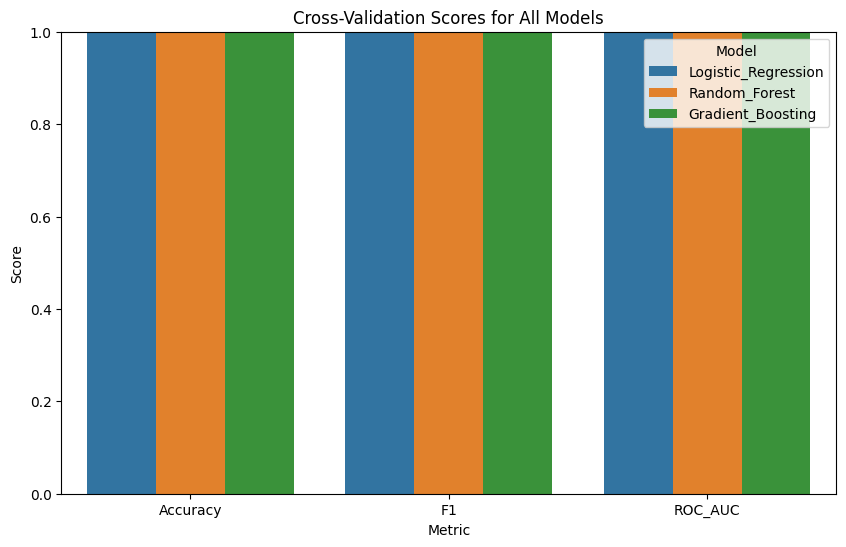

In [75]:
cv_results_melted = cv_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=cv_results_melted)
plt.title("Cross-Validation Scores for All Models")
plt.ylim(0,1)
plt.ylabel("Score")
plt.show()